# House Price Prediction Model

In [1]:
import pandas as pd
import numpy as np
from google.colab import drive

### Mount drive in Google Colab server

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Load data by function pd.read_csv()

In [124]:
!ls drive/MyDrive/data/House-Prediction_Dataset

path = "/content/drive/MyDrive/data/House-Prediction_Dataset/data.csv"
df = pd.read_csv(path)

data.csv  data.dat  output.csv


### Analyse data by taking its head that is basically first 5 rows 

In [171]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


### Check Information About data that is basically information about null values and datatypes of each column

In [172]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4549 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           4549 non-null   datetime64[ns]
 1   price          4549 non-null   float64       
 2   bedrooms       4549 non-null   float64       
 3   bathrooms      4549 non-null   float64       
 4   sqft_living    4549 non-null   int64         
 5   sqft_lot       4549 non-null   int64         
 6   floors         4549 non-null   float64       
 7   waterfront     4549 non-null   int64         
 8   view           4549 non-null   int64         
 9   condition      4549 non-null   int64         
 10  sqft_above     4549 non-null   int64         
 11  sqft_basement  4549 non-null   int64         
 12  yr_built       4549 non-null   int64         
 13  yr_renovated   4549 non-null   int64         
 14  street         4549 non-null   object        
 15  city           4549 non-nu

### Statistical Sumary about Data using describe Function


In [173]:
df.describe()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4549,4.549000e+03,4549.000000,4549.000000,4549.000000,4.549000e+03,4549.000000,4549.000000,4549.000000,4549.000000,4549.000000,4549.000000,4549.000000,4549.000000
mean,2014-06-07 03:52:20.998021632,5.576257e+05,3.396131,2.155968,2131.578809,1.483460e+04,1.511651,0.006595,0.234337,3.449549,1821.291932,310.286876,1970.787206,808.036272
min,2014-05-02 00:00:00,7.800000e+03,1.000000,0.750000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,2014-05-21 00:00:00,3.261000e+05,3.000000,1.750000,1460.000000,5.000000e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,2014-06-09 00:00:00,4.650000e+05,3.000000,2.250000,1970.000000,7.680000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,2014-06-24 00:00:00,6.575000e+05,4.000000,2.500000,2610.000000,1.097000e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,600.000000,1997.000000,1999.000000
max,2014-07-10 00:00:00,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000
std,NaN,5.638915e+05,0.901988,0.775205,955.234941,3.597114e+04,0.537794,0.080949,0.765085,0.675242,853.292493,462.043404,29.763891,979.313181


### Convert date object(string) into date format

In [174]:
df["date"] = pd.to_datetime(df["date"])

### Visualiza Data for batter understanding like Coorelation and Statistical Describution

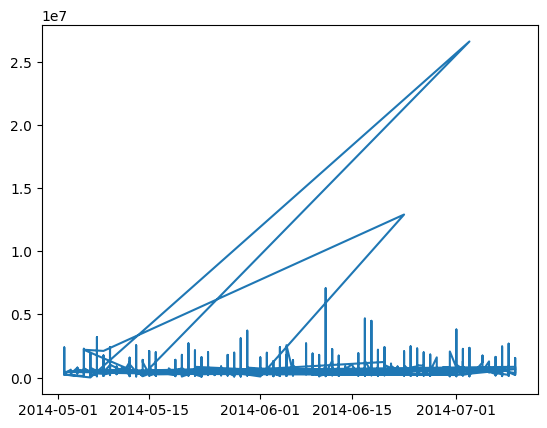

In [175]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.plot(df["date"], df["price"])
plt.show()

In [176]:
df["date"].corr(df["price"])

np.float64(0.032439817062970736)

### try different features to train model and analys the effect

In [177]:
df["date"].corr(df["price"])

np.float64(0.032439817062970736)

In [178]:
len(df[df["bedrooms"] == 0])

0

In [179]:
df = df[df["bedrooms"] > 0]

In [180]:
len(df[df["bathrooms"] == 0])

0

In [181]:
df = df[df["price"] > 0]

In [182]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [183]:
df["city"].value_counts()

,count
city,
Seattle,1560
Renton,291
Bellevue,281
Redmond,234
Kirkland,187
Issaquah,186
Kent,184
Auburn,175
Sammamish,171


In [184]:
X = df[["bedrooms", "bathrooms", "sqft_living", "view", "sqft_above", "sqft_basement", "city", "street"]]
Y = df["price"]


In [185]:
# encode city
X = pd.get_dummies(X, columns=["city", "street"])

In [186]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3639, 4524), (910, 4524), (3639,), (910,))

In [187]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [188]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [189]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)


-0.0554833008574962

In [196]:
df = pd.read_csv(path)

In [197]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [198]:
len(df[df["price"] == 0])

49

In [199]:
# 2.1 Handle the zero-price rows
print(f"Number of rows with price = 0: {len(df[df['price'] == 0])}")
df = df[df['price'] > 0] # Remove them for now (a simple approach)

# 2.2 Convert 'date' to datetime and extract useful features
df['date'] = pd.to_datetime(df['date'])
df['year_sold'] = df['date'].dt.year
df['month_sold'] = df['date'].dt.month
df['day_sold'] = df['date'].dt.day
# We might drop the original 'date' column later as it's now broken down.

# 2.3 Handle 'yr_renovated' - it has many zeros meaning "never renovated"
# Let's create a new feature: 'was_renovated' (1 if renovated, else 0)
df['was_renovated'] = (df['yr_renovated'] > 0).astype(int)

# 2.4 Check for other impossible values
# e.g., bathrooms = 0? bedrooms = 0? sqft_living = 0?
print(f"Rows with 0 bedrooms: {len(df[df['bedrooms'] == 0])}")
df = df[df['bedrooms'] > 0]
print(f"Rows with 0 bathrooms: {len(df[df['bathrooms'] == 0])}")
df = df[df['bathrooms'] > 0]
# ... and so on for other critical features.

# 2.5 Create a new feature: 'house_age' at time of sale
df['house_age'] = df['year_sold'] - df['yr_built']

# 2.6 Create a feature: 'total_sqft' (often more useful than above/below separately)
df['total_sqft'] = df['sqft_living'] # sqft_living already includes above + basement.
# But you can also create 'ratio_basement' = sqft_basement / sqft_living

# 2.7 Handle outliers (using 'sqft_living' as an example)
# Let's cap extreme outliers at the 99th percentile
upper_limit = df['sqft_living'].quantile(0.99)
df['sqft_living_capped'] = np.where(df['sqft_living'] > upper_limit, upper_limit, df['sqft_living'])
# You'd repeat this for 'price', 'sqft_lot', etc.

Number of rows with price = 0: 49
Rows with 0 bedrooms: 2
Rows with 0 bathrooms: 0


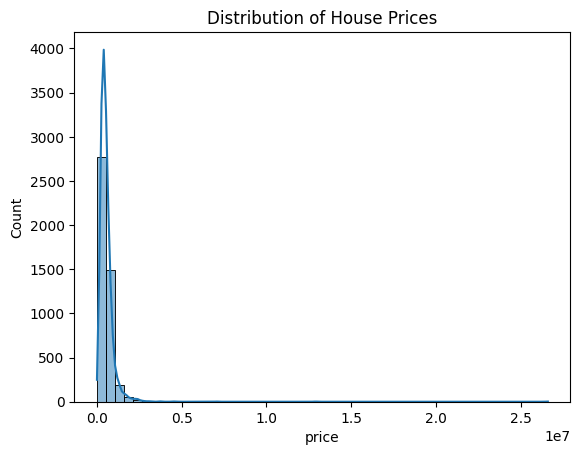

price                 1.000000
total_sqft            0.445042
sqft_living           0.445042
sqft_living_capped    0.421057
sqft_above            0.380060
bathrooms             0.343186
view                  0.242407
sqft_basement         0.218200
bedrooms              0.212814
floors                0.152010
waterfront            0.150167
sqft_lot              0.051317
month_sold            0.040339
condition             0.039238
yr_built              0.021444
house_age            -0.021444
day_sold             -0.023157
was_renovated        -0.029459
yr_renovated         -0.029661
year_sold                  NaN
Name: price, dtype: float64


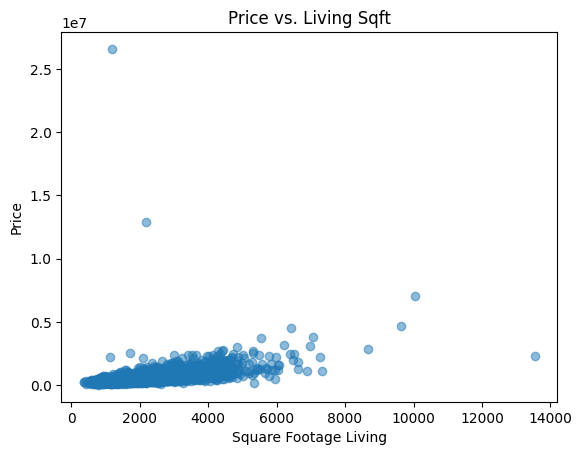

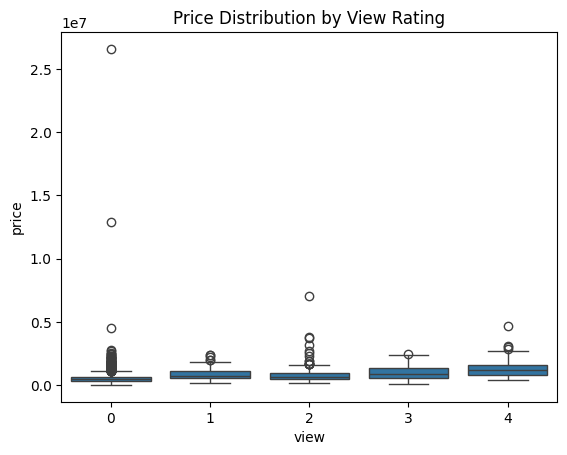

city
Medina                2.046559e+06
Clyde Hill            1.615711e+06
Yarrow Point          1.194838e+06
Mercer Island         1.178638e+06
Bellevue              8.622551e+05
Beaux Arts Village    7.450000e+05
Sammamish             7.029858e+05
Fall City             6.926818e+05
Newcastle             6.660467e+05
Redmond               6.649658e+05
Name: price, dtype: float64


In [200]:
import matplotlib.pyplot as plt
import seaborn as sns

# 3.1 Distribution of the target variable 'price' (it's usually skewed)
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of House Prices')
plt.show()
# If it's highly skewed, a log transformation can help.

# 3.2 Correlation with the target
numeric_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numeric_cols].corr()
price_corr = correlation_matrix['price'].sort_values(ascending=False)
print(price_corr)
# Look for features with high absolute correlation (e.g., >0.5) like 'sqft_living', 'sqft_above'.

# 3.3 Scatter plot for a strong predictor
plt.scatter(df['sqft_living'], df['price'], alpha=0.5)
plt.xlabel('Square Footage Living')
plt.ylabel('Price')
plt.title('Price vs. Living Sqft')
plt.show()
# You should see a positive relationship.

# 3.4 Categorical feature analysis (e.g., 'view')
sns.boxplot(x='view', y='price', data=df)
plt.title('Price Distribution by View Rating')
plt.show()
# Higher view score should correlate with higher price.

# 3.5 Geographic analysis (e.g., average price by 'city')
city_price = df.groupby('city')['price'].mean().sort_values(ascending=False)
print(city_price.head(10))
# Cities like 'Medina', 'Clyde Hill', 'Mercer Island' will likely have the highest prices.

In [204]:
# 4.1 Handle categorical features (like 'city')
# First, see how many unique cities you have
print(f"Number of unique cities: {df['city'].nunique()}")
print(f"Top 10 cities by frequency:\n{df['city'].value_counts().head(10)}")

# For practice, use the top 5 most common cities and group the rest as 'Other'
top_cities = df['city'].value_counts().head(5).index.tolist()
print(f"\nTop 5 cities: {top_cities}")

# Create the grouped city column
df['city_grouped'] = df['city'].apply(lambda x: x if x in top_cities else 'Other')

# Check the distribution after grouping
print(f"\nDistribution after grouping:\n{df['city_grouped'].value_counts()}")

# Now create dummy variables (one-hot encoding)
# The `prefix` parameter will add 'city_grouped_' before each city name
df = pd.get_dummies(df, columns=['city_grouped'], prefix='city_grouped')

# 4.2 SEE what columns were actually created!
# This is the key step you missed - always check after transformation
city_dummy_columns = [col for col in df.columns if col.startswith('city_grouped_')]
print(f"\nCity dummy columns created: {city_dummy_columns}")

# 4.3 Select your final features for the model
# Now use the EXACT column names that were created
features = [
    'bedrooms', 
    'bathrooms', 
    'sqft_living_capped', 
    'floors',
    'waterfront', 
    'view', 
    'condition', 
    'house_age', 
    'was_renovated'
]

# Add ALL the city dummy columns (or select specific ones)
# Add all of them (simpler)
features.extend(city_dummy_columns)

# OR if you want specific cities (using the actual names from above):
# features.extend(['city_grouped_Seattle', 'city_grouped_Bellevue', 'city_grouped_Redmond', 
#                  'city_grouped_Kent', 'city_grouped_Other'])

print(f"\nFinal feature list: {features}")

# 4.4 Create your feature matrix X and target y
X = df[features]  # This should now work!
y = df['price']

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFirst few rows of X:\n{X.head()}")

Number of unique cities: 44
Top 10 cities by frequency:
city
Seattle        1560
Renton          291
Bellevue        281
Redmond         234
Kirkland        187
Issaquah        186
Kent            184
Auburn          175
Sammamish       171
Federal Way     145
Name: count, dtype: int64

Top 5 cities: ['Seattle', 'Renton', 'Bellevue', 'Redmond', 'Kirkland']

Distribution after grouping:
city_grouped
Other       1996
Seattle     1560
Renton       291
Bellevue     281
Redmond      234
Kirkland     187
Name: count, dtype: int64

City dummy columns created: ['city_grouped_Bellevue', 'city_grouped_Kirkland', 'city_grouped_Other', 'city_grouped_Redmond', 'city_grouped_Renton', 'city_grouped_Seattle']

Final feature list: ['bedrooms', 'bathrooms', 'sqft_living_capped', 'floors', 'waterfront', 'view', 'condition', 'house_age', 'was_renovated', 'city_grouped_Bellevue', 'city_grouped_Kirkland', 'city_grouped_Other', 'city_grouped_Redmond', 'city_grouped_Renton', 'city_grouped_Seattle']

X shape: 

In [205]:
from sklearn.model_selection import train_test_split

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

Training set size: 3639 rows
Test set size: 910 rows


In [206]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 6.1 Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# 6.2 Make predictions on the test set
y_pred = model.predict(X_test)

# 6.3 Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Root Mean Squared Error (in dollars)
mae = mean_absolute_error(y_test, y_pred) # Mean Absolute Error (in dollars)
r2 = r2_score(y_test, y_pred) # R-squared (0 to 1, higher is better)

print(f"Root Mean Squared Error: ${rmse:,.2f}")
print(f"Mean Absolute Error: ${mae:,.2f}")
print(f"R-squared Score: {r2:.4f}")

Root Mean Squared Error: $240,344.00
Mean Absolute Error: $148,891.83
R-squared Score: 0.6266


In [207]:
from sklearn.ensemble import RandomForestRegressor

# 7.1 Train a Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 7.2 Predict and Evaluate
y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Results:")
print(f"RMSE: ${rmse_rf:,.2f}")
print(f"MAE: ${mae_rf:,.2f}")
print(f"R2: {r2_rf:.4f}")

# 7.3 Check feature importance (a huge advantage of tree models)
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)
print(feature_importance_df.head(10))

Random Forest Results:
RMSE: $271,864.35
MAE: $155,538.37
R2: 0.5222
                 feature  importance
2     sqft_living_capped    0.378575
7              house_age    0.209090
1              bathrooms    0.080723
6              condition    0.074175
14  city_grouped_Seattle    0.051948
11    city_grouped_Other    0.037544
0               bedrooms    0.034563
3                 floors    0.033766
5                   view    0.029465
4             waterfront    0.027167


In [209]:
from sklearn.model_selection import cross_val_score, GridSearchCV

# Example of Cross-Validation on your linear regression
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
print(f"Cross-Validation R2 scores: {scores}")
print(f"Mean CV R2: {scores.mean():.4f}")

Cross-Validation R2 scores: [0.58387619 0.0420259  0.58006959 0.48828446 0.61394912]
Mean CV R2: 0.4616
